# Plotting Notebook
This notebook is to help you plot your PHREEQC output data.

## Run this cell first to import necessary modules and setup plotting functions

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


def load_phreeqc_output(filepath, sep="\t", **kwargs):
    """Load a tab-delimited PHREEQC .sel/.dat file into a DataFrame.

    Strips whitespace from header names and drops any empty/unnamed
    columns produced by trailing delimiters in the source file.

    The rows are dropped before the pH increases, so the DataFrame will
    only contain the rows after the pH increases.
    """
    df = pd.read_csv(filepath, sep=sep, **kwargs)
    df.columns = df.columns.str.strip()
    df = df.loc[:, ~df.columns.str.match(r"^Unnamed(:.*)?$|^$")]

    return df


def concentration_plot(data, x_col, y_col, drop_rows=None):
    """Plot concentration data from a PHREEQC output DataFrame.

    Parameters:
    - data: DataFrame containing the PHREEQC output.
    - x_col: Column name for the x-axis (e.g., pH).
    - y_col: list of column names for the y-axis (e.g., species concentrations).

    Returns:
    - A matplotlib figure and axis object.
    """
    if drop_rows is not None:
        data = data.drop(drop_rows).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 6))

    for col in y_col:
        ax.plot(data[x_col], data[col], label=col)
    ax.legend()
    ax.set_xlabel(x_col)
    ax.set_ylabel("Concentration (mol/L)")

    return fig, ax


def percent_plot(data, x_col, y_col, total_conc, drop_rows=None):
    """Plot percent data from a PHREEQC output DataFrame.

    Parameters:
    - data: DataFrame containing the PHREEQC output.
    - x_col: Column name for the x-axis (e.g., pH).
    - y_col: list of column names for the y-axis (e.g., species concentrations).
    - total_conc: Column name for the total concentration to calculate percentages.

    Returns:
    - A matplotlib figure and axis object.
    """
    if drop_rows is not None:
        data = data.drop(drop_rows).reset_index(drop=True)

    fig, ax = plt.subplots(figsize=(10, 6))

    for col in y_col:
        percent = (data[col] / total_conc) * 100
        ax.plot(data[x_col], percent, label=col)
    ax.legend()
    ax.set_xlabel(x_col)
    ax.set_ylabel("Percent (%)")

    return fig, ax

# Load your data
Replace `example1.sel` with your filename

In [2]:
data = load_phreeqc_output("example1.sel")
print("You can plot the following columns:")
print(data.columns.tolist())
data

You can plot the following columns:
['pH', 'm_Zn(Edta)-2', 'm_Zn+2', 'm_Zn(OH)2']


,pH,m_Zn(Edta)-2,m_Zn+2,m_Zn(OH)2
0,7.0,0.000070,2.971100e-05,4.473100e-09
1,3.0,0.000022,3.025300e-05,4.162600e-17
2,3.5,0.000040,3.001100e-05,4.356800e-16
3,4.0,0.000057,2.999500e-05,4.458000e-15
4,4.5,0.000065,2.999700e-05,4.496800e-14
5,5.0,0.000068,2.999600e-05,4.509700e-13
6,5.5,0.000069,2.999100e-05,4.513000e-12
7,6.0,0.000070,2.997100e-05,4.511400e-11
8,6.5,0.000070,2.990900e-05,4.502500e-10
9,7.0,0.000070,2.971100e-05,4.473100e-09


# Concentration vs pH

(<Figure size 1000x600 with 1 Axes>,
 <Axes: xlabel='pH', ylabel='Concentration (mol/L)'>)

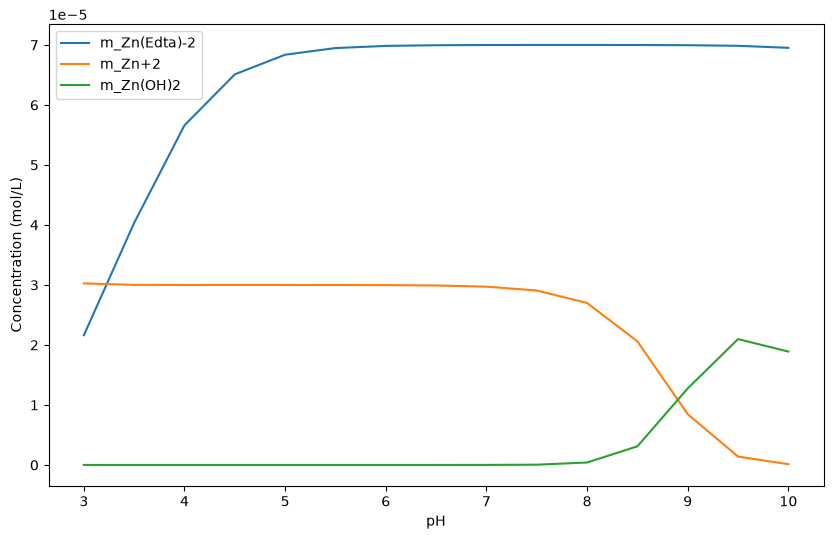

In [3]:
# data to plot
xaxis = "pH"
yaxis = ["m_Zn(Edta)-2", "m_Zn+2", "m_Zn(OH)2"]

# Rows to drop
drop_rows = [0]

concentration_plot(data, xaxis, yaxis, drop_rows=drop_rows)

# Percent vs pH
You need to specify a total concentration in addition to the data to plot

(<Figure size 1000x600 with 1 Axes>, <Axes: xlabel='pH', ylabel='Percent (%)'>)

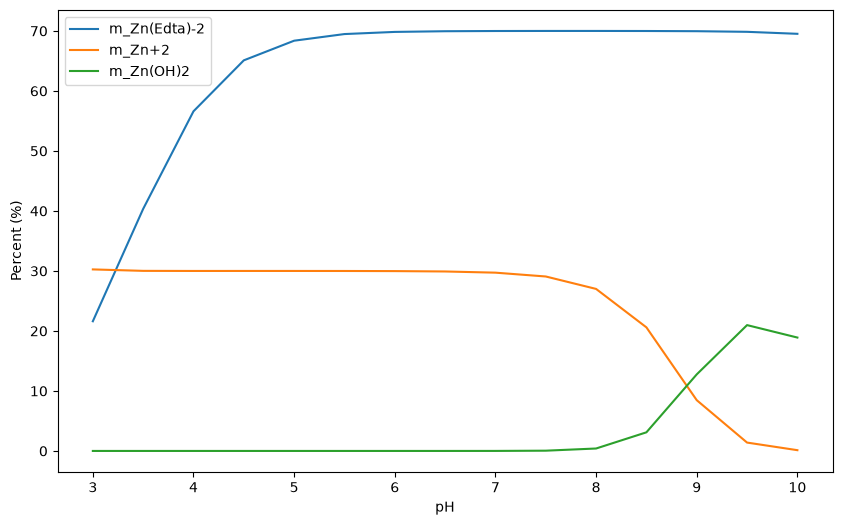

In [6]:
# Total concentration for percent plot
total_conc = 1e-4

# data to plot
xaxis = "pH"
yaxis = ["m_Zn(Edta)-2", "m_Zn+2", "m_Zn(OH)2"]

# Rows to drop
drop_rows = [0]

percent_plot(data, xaxis, yaxis, total_conc, drop_rows=drop_rows)